# Mid-Term Practical Exam

## Part A

In [54]:
from pathlib import Path
import os
import sys
import platform
import json
import random
from pathlib import Path

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

In [67]:
PROJECT_ROOT = Path.cwd() / "midterm_project"

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

NOTEBOOKS = PROJECT_ROOT / "notebooks"

CONFIGS = PROJECT_ROOT / "configs"

REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures"
TABLES = REPORTS / "tables"

REQUIREMENTS = PROJECT_ROOT / "requirements.txt"
README = PROJECT_ROOT / "README.md"

for p in [PROJECT_ROOT, DATA_RAW, DATA_INTERIM, DATA_PROCESSED, REPORTS, CONFIGS, NOTEBOOKS]:
    p.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('c:/Users/Vivi/Documents/Repos/Data-Science/midterm_project')

In [ ]:
SEED = 42

config = {
    "project_root": str(PROJECT_ROOT),
    "data_raw": str(DATA_RAW),
    "data_interim": str(DATA_INTERIM),
    "data_processed": str(DATA_PROCESSED),
    "notebooks": str(NOTEBOOKS),
    "reports": str(REPORTS),
    "configs": str(CONFIGS),
    "seed": SEED,
    "missing_value_strategy": "mean",
    "scaling_strategy": "standard",
    "pca_settings": {
        "n_components": 5
    },
    "clustering_parameters": {
        "n_clusters": None,
        "algorithm": None
    }
}

with open(CONFIGS / "config.json", "w") as f:
    json.dump(config, f, indent=4)

In [26]:
raw_data = pd.read_csv(DATA_RAW / "manufacturing_batch_profiles.csv")
print("Shape:", raw_data.shape)
print("-" * 40)
print("Head:", raw_data.head())
print("-" * 40)
print("Column Names and Types:")
print(raw_data.dtypes)
print("-" * 40)
print("Missing Values:")
print(raw_data.isnull().sum())
print("-" * 40)
print("Duplicate Rows:", raw_data.duplicated().sum())

Shape: (638, 13)
----------------------------------------
Head:   batch_id production_date    plant    shift  temperature_avg_c  \
0    B0001      04-14-2024  Plant_B    Night         225.435300   
1    B0002    May 27, 2023  Plant_B  Evening         213.632580   
2    B0003      01-17-2025  Plant_B  Evening         197.363204   
3    B0004    Aug 18, 2024  Plant_B      Day         192.523520   
4    B0005      2024-03-05  Plant_B      Day         176.011576   

   pressure_avg_bar  vibration_index  cycle_time_sec defect_rate_pct  \
0          4.958596         1.777407           59.50            6.0%   
1          4.656315         2.079549           52.21            5.4%   
2          4.071442         0.989979           46.20             3.2   
3          4.694709         1.386201           59.82             2.4   
4          3.820515         0.741898           35.04            0.1%   

   energy_kwh material_loss_pct  coating_thickness_mm  output_units_per_hr  
0      159.70          

In [29]:
interim_data = raw_data.copy()

# 1. Parse date columns
date_raw = interim_data["production_date"].str.strip()
interim_data["production_date"] = pd.NaT

#YYYY-MM-DD
mask_iso = date_raw.str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)
interim_data.loc[mask_iso, "production_date"] = pd.to_datetime(
    date_raw[mask_iso], format="%Y-%m-%d", errors="coerce"
)

# MM-DD-YYYY
mask_dash_mdY = date_raw.str.match(r"^\d{2}-\d{2}-\d{4}$", na=False)
interim_data.loc[mask_dash_mdY, "production_date"] = pd.to_datetime(
    date_raw[mask_dash_mdY], format="%m-%d-%Y", errors="coerce"
)

# DD/MM/YYYY
mask_slash_dmY = date_raw.str.match(r"^\d{2}/\d{2}/\d{4}$", na=False)
interim_data.loc[mask_slash_dmY, "production_date"] = pd.to_datetime(
    date_raw[mask_slash_dmY], format="%d/%m/%Y", errors="coerce"
)

# 2. Handle missing values by filling with mean
for col in ["temperature_avg_c", "pressure_avg_bar", "vibration_index"]:
    interim_data[col] = interim_data[col].fillna(interim_data[col].mean())

# 3. Convert numeric text fields to numeric types
interim_data["defect_rate_pct"] = interim_data["defect_rate_pct"].str.rstrip("%").astype(float)
interim_data["material_loss_pct"] = interim_data["material_loss_pct"].str.rstrip("%").astype(float)

# 4. Sort by batch_id and reset index
interim_data.sort_values("batch_id", inplace=True)
interim_data.reset_index(drop=True, inplace=True)

In [30]:
# derived column
interim_data["efficiency_score"] = (100 - interim_data["defect_rate_pct"]) * (100 - interim_data["material_loss_pct"])

interim_data.to_csv(DATA_INTERIM / "manufacturing_batch_profiles_interim.csv", index=False)

In [34]:
# 1. Check that there are no missing values
assert interim_data.drop(columns=["production_date"]).isnull().sum().sum() == 0, "There are still missing values in the interim data."

# 2. Check that all numeric columns are of the correct type
numeric_cols = ["temperature_avg_c", "pressure_avg_bar", "vibration_index", "cycle_time_sec", "defect_rate_pct", "energy_kwh", "material_loss_pct", "coating_thickness_mm", "output_units_per_hr"]
for col in numeric_cols:
    assert pd.api.types.is_numeric_dtype(interim_data[col]), f"Column {col} is not numeric."

# 3. Check that production_date is of datetime type
assert pd.api.types.is_datetime64_any_dtype(interim_data["production_date"]), "production_date is not of datetime type."

processed_data = interim_data.copy()
processed_data.to_csv(DATA_PROCESSED / "manufacturing_batch_profiles_processed.csv", index=False)

In [66]:
# requierements.txt
requirements = [
    "pandas",
    "numpy",
    "scipy",
    "scikit-learn",
    "matplotlib"
]
with open(REQUIREMENTS, "w") as f:
    for req in requirements:
        f.write(req + "\n")

In [ ]:
# README.md


## Part B - Univariate Analysis

Chosen variable: `temperature_avg_c`<br/>
Because it is a continuous numeric variable that can provide insights into the thermal conditions during the manufacturing process.

In [36]:
df = pd.read_csv(DATA_PROCESSED / "manufacturing_batch_profiles_processed.csv")
temp = df["temperature_avg_c"]

count = temp.count()
min_val = temp.min()
max_val = temp.max()
mean_val = temp.mean()
median_val = temp.median()
std_val = temp.std()

q1 = temp.quantile(0.25)
q3 = temp.quantile(0.75)
iqr = q3 - q1

print("Temperature Summary")
print(f"Count: {count}")
print(f"Min: {min_val} \t \t Max: {max_val}")
print(f"Mean: {mean_val:.2f} \t Median: {median_val}")
print(f"Standard Deviation: {std_val:.2f}")
print(f"IQR: {iqr} (Q1={q1}, Q3={q3})")

Temperature Summary
Count: 638
Min: 161.68101389950735 	 	 Max: 234.65026586213344
Mean: 199.13 	 Median: 199.1311719332887
Standard Deviation: 14.55
IQR: 22.878748111510447 (Q1=187.96971385540132, Q3=210.84846196691177)


Typically the values in this variable

## Part C

Chosen pair: `temperature_avg_c` and `defect_rate_pct`

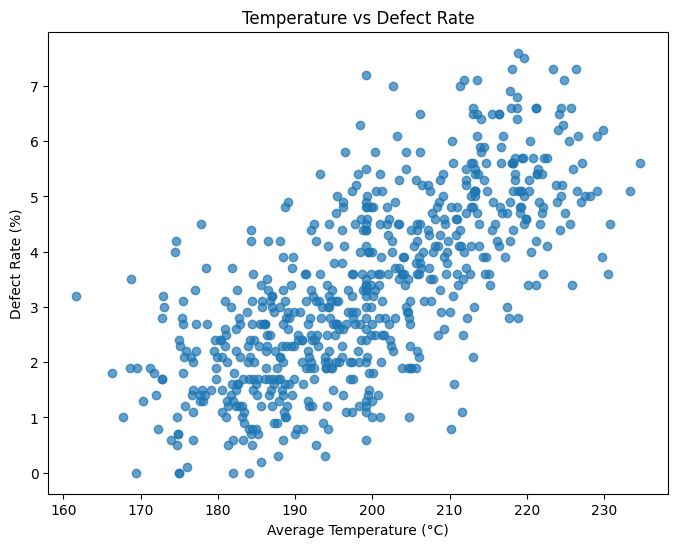

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(df["temperature_avg_c"], df["defect_rate_pct"], alpha=0.7)
plt.title("Temperature vs Defect Rate")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Defect Rate (%)")
plt.show()

In [41]:
covariance = np.cov(df["temperature_avg_c"], df["defect_rate_pct"])[0, 1]
pearson_r, _ = pearsonr(df["temperature_avg_c"], df["defect_rate_pct"])
spearman_rho, _ = spearmanr(df["temperature_avg_c"], df["defect_rate_pct"])
r2 = r2_score(df["defect_rate_pct"], df["temperature_avg_c"])

print(f"Covariance: {covariance:.2f}")
print(f"Pearson r: {pearson_r:.2f}")
print(f"Spearman rho: {spearman_rho:.2f}")
print(f"R^2: {r2:.2f}")


Covariance: 17.02
Pearson r: 0.71
Spearman rho: 0.72
R^2: -14166.41


In [ ]:
# correlation matrix
correlation_matrix = df[["temperature_avg_c", "defect_rate_pct"]].corr()
print(correlation_matrix)

                   temperature_avg_c  defect_rate_pct
temperature_avg_c           1.000000         0.709142
defect_rate_pct             0.709142         1.000000


In [ ]:
# pearson r with outliers
pearson_r_with_outliers, _ = pearsonr(df["temperature_avg_c"], df["defect_rate_pct"])
print(f"Pearson r with outliers: {pearson_r_with_outliers:.2f}")

# pearson r without outliers (remove points outside 1.5*IQR)
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
df_no_outliers = df[(df["temperature_avg_c"] >= lower_bound) & (df["temperature_avg_c"] <= upper_bound)]
pearson_r_no_outliers, _ = pearsonr(df_no_outliers["temperature_avg_c"], df_no_outliers["defect_rate_pct"])
print(f"Pearson r without outliers: {pearson_r_no_outliers:.2f}")

Pearson r with outliers: 0.71
Pearson r without outliers: 0.71


## Part D

In [48]:
numeric_features = df.select_dtypes(include=[np.number]).columns
print("Numeric features:")
for feature in numeric_features:
    print(f"- {feature}")

Numeric features:
- temperature_avg_c
- pressure_avg_bar
- vibration_index
- cycle_time_sec
- defect_rate_pct
- energy_kwh
- material_loss_pct
- coating_thickness_mm
- output_units_per_hr
- efficiency_score


In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[numeric_features])
scaled_df = pd.DataFrame(scaled_features, columns=numeric_features)

In [ ]:
pca = PCA(n_components=5)
pca.fit(scaled_df)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",5
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

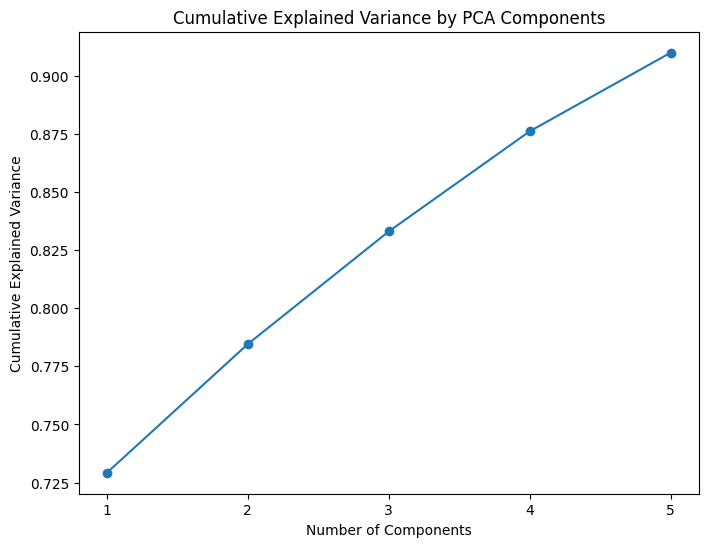

In [ ]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.show()

The smallest number of components that reaches at least 85% variance is 4.

## Part E - Hierarchical Agglomerative Clustering

### E1. Dendrogram

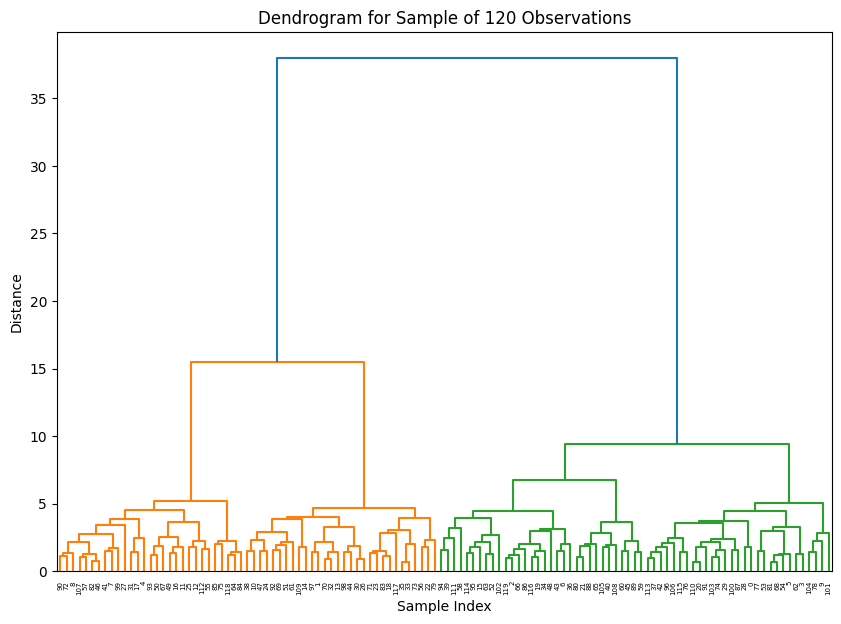

In [63]:
sample_df = scaled_df.sample(n=120, random_state=42)

from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(sample_df, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title("Dendrogram for Sample of 120 Observations")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

In [64]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

for method in ['ward', 'complete']:
    for n_clusters in [3, 4, 5]:
        clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage=method)
        cluster_labels = clustering.fit_predict(scaled_df)
        print(f"Linkage: {method}, Clusters: {n_clusters}, Cluster Sizes: {np.bincount(cluster_labels)}")
        calinski_harabasz = calinski_harabasz_score(scaled_df, cluster_labels)
        davies_bouldin = davies_bouldin_score(scaled_df, cluster_labels)
        silhouette = silhouette_score(scaled_df, cluster_labels)

        print(f"Calinski–Harabasz Index: {calinski_harabasz:.2f}")
        print(f"Davies–Bouldin Index: {davies_bouldin:.2f}")
        print(f"Silhouette Score: {silhouette:.2f}")
        print()



Linkage: ward, Clusters: 3, Cluster Sizes: [318 175 145]
Calinski–Harabasz Index: 594.15
Davies–Bouldin Index: 1.13
Silhouette Score: 0.32

Linkage: ward, Clusters: 4, Cluster Sizes: [185 133 145 175]
Calinski–Harabasz Index: 461.28
Davies–Bouldin Index: 1.68
Silhouette Score: 0.21

Linkage: ward, Clusters: 5, Cluster Sizes: [133 175 145 140  45]
Calinski–Harabasz Index: 365.34
Davies–Bouldin Index: 1.88
Silhouette Score: 0.18

Linkage: complete, Clusters: 3, Cluster Sizes: [319 184 135]
Calinski–Harabasz Index: 581.27
Davies–Bouldin Index: 1.15
Silhouette Score: 0.32

Linkage: complete, Clusters: 4, Cluster Sizes: [230 184 135  89]
Calinski–Harabasz Index: 446.66
Davies–Bouldin Index: 1.63
Silhouette Score: 0.19

Linkage: complete, Clusters: 5, Cluster Sizes: [167  63 135  89 184]
Calinski–Harabasz Index: 348.86
Davies–Bouldin Index: 2.17
Silhouette Score: 0.16



### E2. Model Selection